In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
 

In [2]:
# State
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strick_rate: float
    balls_per_boundry: float
    boundry_percent: float
    summary:str

In [6]:
def calculate_strick_rate(state: BatsmanState) -> BatsmanState:
    return  {"strick_rate": (state['runs']/state['balls'])*100}

def calculate_balls_per_boundry(state: BatsmanState) -> BatsmanState:
    return {"balls_per_boundry": state['balls']/(state['fours'] + state['sixes'])}

def calculate_boundry_percent(state: BatsmanState) -> BatsmanState:
    return {"boundry_percent": (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100}

def summary(state:BatsmanState) -> BatsmanState:
    summary = f"""
    Strick Rate - {state['strick_rate']}
    Balls per Boundry - {state['balls_per_boundry']}
    Boundry Percentage - {state['boundry_percent']}
    """
    return {"summary": summary} 

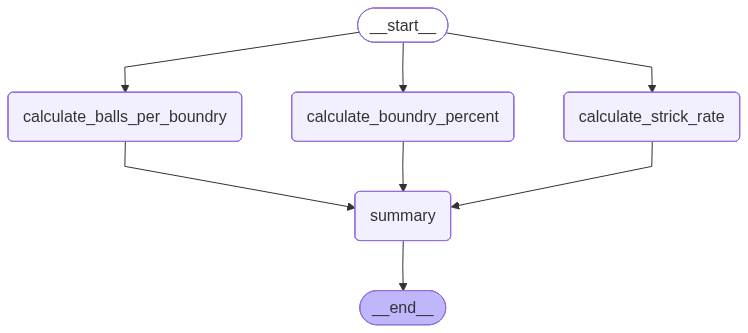

In [7]:
graph = StateGraph(BatsmanState)

# Add Nodes
graph.add_node("calculate_strick_rate", calculate_strick_rate)
graph.add_node("calculate_balls_per_boundry", calculate_balls_per_boundry)
graph.add_node("calculate_boundry_percent", calculate_boundry_percent)
graph.add_node("summary", summary)

# Add Edges
graph.add_edge(START, 'calculate_strick_rate')
graph.add_edge(START, 'calculate_balls_per_boundry')
graph.add_edge(START, 'calculate_boundry_percent')
graph.add_edge("calculate_strick_rate", "summary")
graph.add_edge("calculate_balls_per_boundry", "summary")
graph.add_edge("calculate_boundry_percent", "summary")
graph.add_edge("summary", END)

workflow = graph.compile()
workflow

In [8]:
input = {"runs": 100, "balls":50, "fours":6, "sixes": 4}
final_state = workflow.invoke(input)
final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'strick_rate': 200.0,
 'balls_per_boundry': 5.0,
 'boundry_percent': 48.0,
 'summary': '\n    Strick Rate - 200.0\n    Balls per Boundry - 5.0\n    Boundry Percentage - 48.0\n    '}